In [33]:
import pandas as pd
import numpy as np
import joblib

In [2]:
import random
np.random.seed(42)
random.seed(42)

 ## Loading the Final Merged Dataset
1. We begin by loading the final merged dataset into Python.
2. The dataset is loaded and column names are cleaned to remove inconsistencies such as leading/trailing spaces.
3. low_memory=False ensures consistent type inference across large datasets.

This ensures consistency in further processing steps.

In [3]:
df = pd.read_csv("Final Dataset.csv", low_memory=False)
df.columns = df.columns.str.strip()
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (346463, 24)


,IncidentRequestID,Title,Classification,SubCategory,SubCategoryItem1,RequestType,Region,Impact,Urgency,Priority,...,CreatedOn,ResolveBy,ResolvedDate,AssignmentStartDate,AssignmentEndDate,Status,HelpdeskStatus,AnalystStatus,IsVIPRequired,ActualResolvedBy
0,178409,Unable to authenticate outlook via sms/call,End User Services,Email,NaN,IR,US,Low,Medium,4,...,01/06/22 0:01,01:00.0,39:59.0,01:11.0,39:59.0,Resolved,Completed,Resolved,FALSE,01:00.0
1,178410,Laptop won't charge,End User Services,Hardware Issue,NaN,IR,US,Low,Medium,4,...,01/06/22 0:07,07:00.0,03:30.0,07:30.0,03:30.0,Resolved,Completed,Resolved,FALSE,07:00.0
2,178411,ASMA BADGE: Activation Request – jlittle,Global Service Desk,Badge Request,Badge Activation,SR,GSD,Low,Medium,4,...,01/06/22 0:17,17:00.0,08:02.0,17:29.0,08:02.0,Resolved,Completed,Resolved,FALSE,17:00.0
3,178412,OOD data -31st May'22 - ASMAPLN1929,EUC - Windows Support,Security Request,Others,SR,US,Low,Medium,4,...,01/06/22 0:28,28:00.0,42:30.0,28:50.0,42:30.0,Resolved,Completed,Resolved,FALSE,28:00.0
4,178413,OOD data -31st May'22 - ASMSGGDV1019,EUC - Windows Support,Security Incidents,Anti Virus OOD,IR,SG - Infra,Low,Medium,4,...,01/06/22 0:29,29:00.0,44:37.0,29:09.0,44:37.0,Resolved,Completed,Resolved,FALSE,29:00.0


## Date Conversion

Date columns are converted into datetime format to enable time-based calculations.

This allows extraction of temporal features and accurate computation of resolution times.

In [4]:
date_cols = [
    "CreatedOn",
    "ResolveBy",
    "ResolvedDate",
    "AssignmentStartDate",
    "AssignmentEndDate"
]

In [5]:
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

/var/folders/_4/x1v17k_j46704jcbqp5b0wxm0000gn/T/ipykernel_52558/3042314991.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)
/var/folders/_4/x1v17k_j46704jcbqp5b0wxm0000gn/T/ipykernel_52558/3042314991.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)
/var/folders/_4/x1v17k_j46704jcbqp5b0wxm0000gn/T/ipykernel_52558/3042314991.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True

## Data Inspection

The dataset structure, data types, and missing values are examined.

This step helps identify data quality issues before preprocessing.

In [6]:
df[date_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 346463 entries, 0 to 346462
Data columns (total 5 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   CreatedOn            346451 non-null  datetime64[ns]
 1   ResolveBy            153915 non-null  datetime64[ns]
 2   ResolvedDate         207303 non-null  datetime64[ns]
 3   AssignmentStartDate  137444 non-null  datetime64[ns]
 4   AssignmentEndDate    133241 non-null  datetime64[ns]
dtypes: datetime64[ns](5)
memory usage: 13.2 MB


In [7]:
df[date_cols].isnull().sum()

CreatedOn                  12
ResolveBy              192548
ResolvedDate           139160
AssignmentStartDate    209019
AssignmentEndDate      213222
dtype: int64

## Computing Resolution Time
Resolution time represents how long it took to close a ticket.

1. The difference between ResolvedDate and CreatedOn gives the total duration.
2. The result is converted to hours for interpretability.
3. Open or invalid records may produce NaN or negative values, which are removed to ensure data quality.

In [8]:
df['resolution_time_hours'] = (
    df['ResolvedDate'] - df['CreatedOn']
).dt.total_seconds() / 3600

In [9]:
df['resolution_time_hours'].describe()

count    207303.000000
mean       7229.697544
std       11271.268385
min         -24.000000
25%          15.391667
50%          84.166667
75%       16838.666667
max       33833.966667
Name: resolution_time_hours, dtype: float64

#### Some records showed negative durations (data errors). These were removed:
Only 15 rows were affected, preserving data integrity.

In [10]:
df = df[df['resolution_time_hours'] >= 0]

## Creating the SLA Breach Target Variable
The primary modelling objective is to predict SLA breaches.
An SLA breach occurs when:
ResolvedDate > ResolveBy

Explanation:
> 1. 1 → SLA breached
> 2. 0 → SLA met
> 3. Only records with valid SLA deadlines and resolution dates are considered.
> 4. The dataset shows approximately 10% breach rate, which reflects moderate class imbalance.
> 5. This binary formulation converts the business rule into a supervised learning problem.

In [11]:
df['sla_breach'] = (
    (df['ResolvedDate'] > df['ResolveBy']) &
    df['ResolveBy'].notna() &
    df['ResolvedDate'].notna()
).astype(int)

In [12]:
df['sla_breach'].value_counts()

sla_breach
0    186014
1     21274
Name: count, dtype: int64

## Creating the Modelling Dataset

To ensure accurate SLA breach prediction, we restrict the dataset to records where:
1. An SLA deadline (ResolveBy) exists
2. The ticket has been resolved (ResolvedDate exists)

Open tickets or records without defined SLA deadlines cannot be reliably classified as breached or non-breached. Therefore, they are excluded from the modelling dataset.
This step prevents data leakage and ensures only valid labelled data is used for training.

Explanation:
1. notna() ensures only valid SLA-defined and resolved tickets are included.
2. .copy() prevents unintended modification of the original dataframe.
3. The resulting modelling dataset contains 92,885 records, which will be used for SLA breach prediction.
4. This step ensures that the target variable (sla_breach) is logically valid and that the machine learning model is trained on meaningful data.

In [13]:
df_model = df[
    df['ResolveBy'].notna() & 
    df['ResolvedDate'].notna()
].copy()

df_model["created_hour"] = df_model["CreatedOn"].dt.hour
df_model["created_dayofweek"] = df_model["CreatedOn"].dt.dayofweek
print("Modelling dataset shape:", df_model.shape)

Modelling dataset shape: (92888, 28)


## Feature Engineering

Time-based features were extracted from CreatedOn:

• created_hour → captures time-of-day patterns  
• created_dayofweek → captures weekly trends  

These features help the model identify temporal patterns in SLA breaches.

In [14]:
feature_cols = [
    "Classification",
    "SubCategory",
    "SubCategoryItem1",
    "RequestType",
    "Region",
    "Impact",
    "Urgency",
    "Priority",
    "IsVIPRequired",
    "created_hour", 
    "created_dayofweek"
]

X = df_model[feature_cols].copy()
y = df_model["sla_breach"].copy()


categorical_cols = X.select_dtypes(include="object").columns
X[categorical_cols] = X[categorical_cols].fillna("Unknown")

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_cols:
    X[col] = X[col].fillna(X[col].median())
    
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (92888, 11)
Target shape: (92888,)


## Feature Selection for SLA Breach Modelling

After constructing the modelling dataset, the next step is selecting relevant predictor variables (features) for training the machine learning model.

The target variable is:
	•	sla_breach → Binary indicator (1 = Breach, 0 = No Breach)

We exclude:
	•	Raw date columns (CreatedOn, ResolveBy, ResolvedDate, etc.)
	•	Resolution duration (to avoid leakage)
	•	Any post-resolution fields that would unfairly inform the model

We retain operational and contextual features that are known at the time of ticket handling.

Explanation
1. X contains categorical and derived temporal features.
2. y contains the binary SLA breach label.
3. The modelling dataset contains 92,885 observations.

This ensures:
1. No target leakage
2. Only relevant business context features are used
3. A clean separation between predictors (X) and target (y)

The dataset is now structurally ready for preprocessing and encoding prior to machine learning training.

In [15]:
X.isnull().sum().sort_values(ascending=False)

Classification       0
SubCategory          0
SubCategoryItem1     0
RequestType          0
Region               0
Impact               0
Urgency              0
Priority             0
IsVIPRequired        0
created_hour         0
created_dayofweek    0
dtype: int64

## Categorical Encoding

### Feature Encoding for Machine Learning

Since all selected predictors are categorical variables, they must be transformed into numeric format before training machine learning models.

We apply One-Hot Encoding to convert each category into binary indicator variables.

Explanation
1. pd.get_dummies() converts categorical variables into binary columns.
2. drop_first=True prevents perfect multicollinearity (important for Logistic Regression).
3. The resulting dataset contains 2,312 encoded features.

Although the feature count increased significantly, this is expected when encoding high-cardinality categorical variables such as AssignedToName and SubCategory.

The dataset is now fully numeric and ready for model training.

In [16]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Encoded feature shape:", X_encoded.shape)

Encoded feature shape: (92888, 1851)


In [17]:
print("Final Shape", X_encoded.shape)

Final Shape (92888, 1851)


## Train-Test Split for Model Development

> At this stage, the processed dataset is divided into training and testing subsets. This step is essential to evaluate how well the machine learning model generalizes to unseen data.

> The `train_test_split` function is used with a test size of 20%, meaning that 80% of the data is used for training the model while the remaining 20% is reserved for evaluation. A fixed `random_state` is applied to ensure reproducibility of results.

> Stratified sampling is used based on the target variable `y`. This ensures that the distribution of SLA breach and non-breach cases remains consistent in both training and testing sets, which is particularly important in scenarios where class imbalance exists.

> Finally, the shapes of the resulting datasets are printed to confirm that the split has been performed correctly.

In [18]:
import sklearn
import xgboost
import matplotlib
import seaborn

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (74310, 1851)
Test shape: (18578, 1851)


## Logistic Regression Model for SLA Breach Prediction

## Logistic Regression Model

A Logistic Regression model is used as a baseline for predicting SLA breaches. The model is configured with `class_weight='balanced'` to handle class imbalance and `max_iter=1000` to ensure proper convergence.

After training on the dataset, predictions and probability scores are generated for the test set. The model is evaluated using ROC-AUC to measure classification performance across thresholds, along with a classification report to analyse precision, recall, and F1-score.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.9068702742246966

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.82      0.88     14323
           1       0.59      0.89      0.71      4255

    accuracy                           0.83     18578
   macro avg       0.78      0.85      0.80     18578
weighted avg       0.88      0.83      0.84     18578



## Feature Name Cleaning and Data Split

1. The feature names are cleaned by removing special characters such as `[`, `]`, and `<`. This is required because certain machine learning models like XGBoost may not handle special characters properly in column names.

2. After modifying the feature names, the dataset is re-split into training and testing sets. This ensures consistency and avoids any mismatch caused by changes in the feature structure.

3. Stratified sampling is applied during the split to maintain the distribution of the target variable, ensuring reliable and unbiased model evaluation.

In [21]:
X_encoded.columns = (
    X_encoded.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)

Train shape: (74310, 1851)


## XGBoost Model for SLA Breach Prediction

1. An XGBoost classifier is implemented to improve performance over the baseline model. XGBoost is a powerful ensemble method that captures complex patterns and interactions within the data.

2. The parameter `scale_pos_weight` is used to handle class imbalance by giving higher importance to the minority class. Other parameters such as `n_estimators`, `max_depth`, and `learning_rate` are set to balance model complexity and performance.

3. After training, predictions and probability scores are generated for the test set. The model is evaluated using ROC-AUC and a classification report to assess its ability to distinguish between SLA breach and non-breach cases.

In [22]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:31:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC-AUC: 0.917738859039716

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.82      0.89     14323
           1       0.60      0.90      0.72      4255

    accuracy                           0.84     18578
   macro avg       0.78      0.86      0.80     18578
weighted avg       0.88      0.84      0.85     18578



## Model Evaluation and Confusion Matrix

1. The model performance is evaluated using ROC-AUC and a classification report. ROC-AUC measures how well the model distinguishes between classes, while the classification report provides detailed metrics such as precision, recall, and F1-score.

2. A confusion matrix is generated to visualize the model’s prediction performance. It shows the number of correct and incorrect predictions across actual and predicted classes.

3. The confusion matrix is displayed using a heatmap-style plot, making it easier to interpret how well the model performs in identifying SLA breach and non-breach cases.

ROC-AUC: 0.917738859039716
              precision    recall  f1-score   support

           0       0.96      0.82      0.89     14323
           1       0.60      0.90      0.72      4255

    accuracy                           0.84     18578
   macro avg       0.78      0.86      0.80     18578
weighted avg       0.88      0.84      0.85     18578



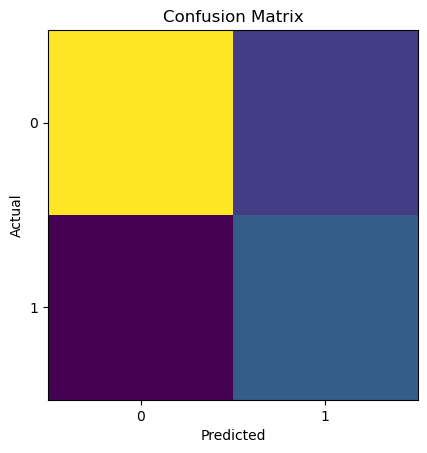

[[11807  2516]
 [  444  3811]]


In [23]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1])
plt.yticks([0,1])
plt.show()

print(cm)

## Feature Importance Analysis

1. Feature importance scores are extracted from the trained XGBoost model to understand which features contribute most to the prediction of SLA breaches.

2. A dataframe is created to map each feature with its corresponding importance score, and the features are sorted in descending order to identify the most influential ones.

3. The top features are displayed to provide insights into key factors affecting SLA performance, which can also help in improving model interpretability and decision-making.

In [24]:
importance = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance', ascending=False
)

feature_importance_df.head(20)

,Feature,Importance
1842,Urgency_Unknown,0.508879
794,SubCategory_Unknown,0.030831
245,Classification_Security Incidents,0.018520
1073,SubCategoryItem1_DNS issue,0.016958
87,Classification_End User Services - US,0.014411
1826,Region_SG - Apps,0.010903
208,Classification_SAP FSM,0.009401
1832,Region_US,0.008812
217,Classification_SAP MM,0.008020
455,SubCategory_Elastic Ops / Azure,0.007743


## Threshold Tuning for Model Optimization

1. Different probability thresholds are tested to evaluate how the model’s predictions change when classifying SLA breaches. Instead of using the default threshold of 0.5, multiple thresholds are explored.

2. For each threshold, predictions are generated based on predicted probabilities, and key metrics such as precision, recall, and F1-score are calculated.

3. This analysis helps identify the optimal threshold that balances precision and recall, which is important in scenarios where false positives and false negatives have different impacts.

In [25]:

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    y_pred_custom = (y_prob_xgb >= t).astype(int)
    
    precision = precision_score(y_test, y_pred_custom)
    recall = recall_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)
    
    print(f"Threshold: {t}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")
    print("-"*30)

Threshold: 0.3
Precision: 0.542
Recall: 0.948
F1-score: 0.689
------------------------------
Threshold: 0.4
Precision: 0.577
Recall: 0.925
F1-score: 0.710
------------------------------
Threshold: 0.5
Precision: 0.602
Recall: 0.896
F1-score: 0.720
------------------------------
Threshold: 0.6
Precision: 0.618
Recall: 0.867
F1-score: 0.722
------------------------------
Threshold: 0.7
Precision: 0.623
Recall: 0.853
F1-score: 0.720
------------------------------


## Cross-Validation and Root Cause Dataset Preparation

1. Stratified K-Fold cross-validation is applied to evaluate the model’s performance more robustly. This technique splits the dataset into multiple folds while preserving class distribution, ensuring reliable and unbiased evaluation.

2. The model is evaluated using ROC-AUC across 5 folds, and the mean and standard deviation of the scores are calculated. This provides a more stable estimate of model performance compared to a single train-test split.

3. A separate dataset is then prepared for root cause analysis by filtering records with valid resolution categories. This dataset will be used for multi-class prediction of resolution types.

In [26]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

xgb_cv_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_scores = cross_val_score(
    xgb_cv_model,
    X_encoded,
    y,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print("Cross-Validation ROC-AUC Scores:", roc_scores)
print("Mean ROC-AUC:", roc_scores.mean())
print("Std Deviation:", roc_scores.std())

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:32:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:32:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:32:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [17:32:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Cross-Validation ROC-AUC Scores: [0.9203897  0.91744226 0.92114239 0.91559256 0.91660385]
Mean ROC-AUC: 0.9182341523505595
Std Deviation: 0.0021618158446608583


In [27]:
df_root = df_model.copy()

df_root = df_root[df_root['ResolutionCategory'].notna()].copy()

print("Root cause dataset shape:", df_root.shape)

Root cause dataset shape: (80966, 28)


## Root Cause Feature Preparation and Encoding

1. The target variable `ResolutionCategory` is selected for multi-class classification, while relevant feature columns are extracted to form the input dataset for root cause prediction.

2. Missing values in categorical features are handled by replacing them with "Unknown" to ensure no data is lost during preprocessing.

3. One-hot encoding is applied to convert categorical variables into numerical format, and column names are cleaned to remove special characters for compatibility with XGBoost.

In [28]:
y_root = df_root["ResolutionCategory"].copy()

feature_cols_root = [
    "Classification",
    "SubCategory",
    "SubCategoryItem1",
    "RequestType",
    "Region",
    "Impact",
    "Urgency",
    "Priority",
    "HelpdeskStatus",
    "AnalystStatus",
    "IsVIPRequired"
]

X_root = df_root[feature_cols_root].copy()

X_root = X_root.fillna("Unknown")

X_root_encoded = pd.get_dummies(X_root, drop_first=True)

X_root_encoded.columns = (
    X_root_encoded.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
)

print("Encoded root feature shape:", X_root_encoded.shape)
print("Number of classes:", y_root.nunique())

Encoded root feature shape: (80966, 1650)
Number of classes: 8


## Multi-Class Root Cause Model and Class Balancing

1. The dataset is aligned to ensure that feature and target variables have matching indices, followed by encoding the target variable into numerical labels using LabelEncoder.

2. To address severe class imbalance, categories with very low sample sizes are removed by keeping only classes with sufficient observations. The labels are then re-encoded to maintain a continuous class range required for multi-class classification.

3. The dataset is split using stratified sampling, and an XGBoost model is trained for multi-class prediction. The model is evaluated using accuracy and a classification report, with additional focus on macro F1-score to assess performance across all classes.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
import pandas as pd

X_root_encoded, y_root = X_root_encoded.align(y_root, join="inner", axis=0)
 
le = LabelEncoder()
y_root_encoded = le.fit_transform(y_root)

y_series = pd.Series(y_root_encoded, index=X_root_encoded.index)
class_counts = y_series.value_counts()

valid_classes = class_counts[class_counts >= 50].index

mask = y_series.isin(valid_classes)

X_root_encoded = X_root_encoded[mask]
y_series = y_series[mask]

le = LabelEncoder()
y_root_encoded = le.fit_transform(y_series)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_root_encoded,
    y_root_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_root_encoded
)

print("Train shape:", Xr_train.shape)
print("Test shape:", Xr_test.shape)


# XGBoost Model
xgb_root = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softprob',
    num_class=len(set(y_root_encoded)),
    random_state=42,
    eval_metric='mlogloss'
)

xgb_root.fit(Xr_train, yr_train)

yr_pred = xgb_root.predict(Xr_test)

print("Accuracy:", accuracy_score(yr_test, yr_pred))
print("\nClassification Report:\n")
print(classification_report(yr_test, yr_pred))

Train shape: (64761, 1650)
Test shape: (16191, 1650)
Accuracy: 0.981718238527577

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     15805
           1       0.65      0.37      0.47       287
           2       0.95      0.42      0.59        99

    accuracy                           0.98     16191
   macro avg       0.86      0.60      0.68     16191
weighted avg       0.98      0.98      0.98     16191



In [30]:
pd.Series(y_root).value_counts(normalize=True)

ResolutionCategory
Fixed by Analyst                0.975965
Fixed by External IT Team       0.017748
Fixed by Higher Tier Support    0.006114
Resolved by Analyst             0.000086
Cancelled                       0.000049
Software Fix                    0.000012
Network Fix                     0.000012
Access Management               0.000012
Name: proportion, dtype: float64

In [31]:
print("Macro F1:", 
      classification_report(yr_test, yr_pred, output_dict=True)['macro avg']['f1-score'])

Macro F1: 0.6822944105400225


In [32]:
print("Final Dataset Shape:", X_encoded.shape)
print("Missing Values:", X_encoded.isnull().sum().sum())

Final Dataset Shape: (92888, 1851)
Missing Values: 0


In [35]:

joblib.dump(xgb_model, "sla_breach_model.joblib")
joblib.dump(X_encoded.columns, "sla_model_columns.joblib")
joblib.dump(xgb_root, "root_cause_model.joblib")
joblib.dump(X_root_encoded.columns, "root_model_columns.joblib")
joblib.dump(le, "root_label_encoder.joblib")

print("All models saved successfully")

All models saved successfully


## Conclusion

The developed machine learning models successfully predict SLA breaches and provide insights into root cause categories. 

Class imbalance was addressed through preprocessing and model techniques, resulting in improved performance across key metrics such as F1-score.

Overall, the solution demonstrates an effective application of machine learning for improving IT incident management and operational efficiency.